In [2]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install sklearn
!pip install folium
!pip install os
!pip install re
!pip install random
!pip install json

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import folium
import os
import re
import random
import json

# 1. data_gzip

In [5]:
import data_gzip

In [6]:
# 염색체 파일을 압축 해제하고 저장 (예시 : 16부터 17까지)
data_gzip.extract_and_process_vcfs(start_chromosome=16, end_chromosome=17, output_dir='./data')

./data/1kGP_high_coverage_Illumina.chr16.filtered.SNV_INDEL_SV_phased_panel.vcf.gz 파일을 압축 해제하여 ./data/chr16에 저장했습니다.
./data/1kGP_high_coverage_Illumina.chr17.filtered.SNV_INDEL_SV_phased_panel.vcf.gz 파일을 압축 해제하여 ./data/chr17에 저장했습니다.


# 2-1. snp_Alzheimer

In [7]:
import snp_Alzheimer

## 알츠하이머 관련 snp 포지션, 크로모좀

- https://www.snpedia.com/index.php/Alzheimer%27s_disease 참고

- MAPT - rs1800547 : Chromosome 17 / Position 45974480

- APOE - rs7412 : Chromosome 19 / Position 44908822, 
           rs429358 : Chromosome 19 / Position 44908684

- SORL1 - rs2070045 : Chromosome 11 / Position 121577381

- ABCA2 - rs908832 : Chromosome 9 / Position 137018032

- GAB2 - rs2373115 : Chromosome 11 / Position 78380104

- BACE1 - rs4938369 : Chromosome 11 / Position 117317404

- CETP - rs5882 : Chromosome 16 / Position 56982180

- PPP3R1 - rs1868402 : Chromosome 2 / Position 68181905

- APP-rs63750847 : Chromosome 21 / Position 25897620

- PLD3 - rs145999145 : Chromosome 19 / Position 40371688

- TREM2 - rs75932628 : Chromosome 6 / Position 41161514

- OLR1 - rs1050283 : Chromosome 12 / Position 10159690

- ACE - rs4293 : Chromosome 17 / Position 63478305, 
       - rs1799752 : Chromosome 17 / Position 63488529

- MPO - rs2333227 : Chromosome 17 / Position 58281401

- A2M - rs669 : Chromosome 12 / Position 9079672

- DAPK1 - rs4878104 : Chromosome 9 / Position 87578076,    
             rs4877365 : Chromosome 9 / Position 87540777

- MME - rs1836915 : Chromosome 3 / Position 155091313

- TLR4 - rs4986790 : Chromosome 9 / Position 117713024

- TM2D3 - rs139709573 : Chromosome	15 / Position	101646763

- A2M - rs669 : Chromosome	12 /  Position	9079672

- PLAU - rs2227564 : Chromosome	10 / Position	73913343, 
          - rs2227562 :  Chromosome	10 / Position	73913203, 
          - rs4065 : Chromosome	10 / Position	73916706

- GAB2 - rs2373115 : Chromosome	11 / Position	78380104, 
          - rs1385600 : Chromosome	11 /  Position	78225120, 
          - rs4945261 : Chromosome	11 / Position	78279214, 
         - rs7101429 : Chromosome	11 / Position	78281921, 
         -rs10793294 : Chromosome	11 / Position	78285357, 
         - rs7115850 : Chromosome	11 / Position	78334025

- CALHM1 - rs11191692 : Chromosome   10 / Position 103454008, 
                 rs2986017 : Chromosome 10 / Position 103458495, 
                 rs371900329 : Chromosome   10 / Position 103458291, 
                 rs729211 : Chromosome 10 / Position 103455175

- GOLM1 - rs10868366 : Chromosome 9 / Position 86085145, 
               rs7019241 : Chromosome 9 / Position 86078545

- NoGene - rs9886784 : Chromosome 9 / Position 1521204

- BDNF - rs6265 : Chromosome 11 / Position 27658369, 
            rs11030104 : Chromosome 11 / Position 27662970, 
            rs2049045 : Chromosome 11 / Position   27672694
 
- DNMBP - rs10883421 : Chromosome 10 / Position 99912584, 
                rs3740057 : Chromosome 10 / Position 99898828, 
                rs3740058 : Chromosome 10 / Position 99896225
                
                
27개

## 알츠하이머 관련 snp 데이터 프레임

- EX) CETP - rs5882 : Chromosome 16 / Position 56982180

In [8]:
# 사용 예시
input_file = './data/chr16' 
desired_positions = ['56982180']
result = snp_Alzheimer.find_snp_by_positions(input_file, desired_positions)

# 결과 출력
for line_number, chrom, position, snp_info, columns in result:
    #print(f'Line Number: {line_number}, Chromosome: {chrom}, Position: {position}, SNP Info: {snp_info}')
    print(f'Columns: {columns}')

Columns: ['chr16', '56982180', '16:56982180:G:A', 'G', 'A', '.', '.', 'AC=3390;AF=0.529357;CM=74.7843;AN=6404;AN_EAS=1170;AN_AMR=980;AN_EUR=1266;AN_AFR=1786;AN_SAS=1202;AN_EUR_unrel=1006;AN_EAS_unrel=1008;AN_AMR_unrel=694;AN_SAS_unrel=978;AN_AFR_unrel=1322;AF_EAS=0.555556;AF_AMR=0.595918;AF_EUR=0.672986;AF_AFR=0.361142;AF_SAS=0.548253;AF_EUR_unrel=0.668986;MAF_EUR_unrel=0.331014;AF_EAS_unrel=0.563492;MAF_EAS_unrel=0.436508;AF_AMR_unrel=0.599424;MAF_AMR_unrel=0.400576;AF_SAS_unrel=0.550102;MAF_SAS_unrel=0.449898;AF_AFR_unrel=0.36233;MAF_AFR_unrel=0.36233;AC_EAS=650;AC_AMR=584;AC_EUR=852;AC_AFR=645;AC_SAS=659;AC_EUR_unrel=673;AC_EAS_unrel=568;AC_AMR_unrel=416;AC_SAS_unrel=538;AC_AFR_unrel=479;AC_Het_EAS=284;AC_Het_AMR=234;AC_Het_EUR=262;AC_Het_AFR=395;AC_Het_SAS=295;AC_Het_EUR_unrel=211;AC_Het_EAS_unrel=238;AC_Het_AMR_unrel=162;AC_Het_SAS_unrel=238;AC_Het_AFR_unrel=291;AC_Het=1470;AC_Hom_EAS=366;AC_Hom_AMR=350;AC_Hom_EUR=590;AC_Hom_AFR=250;AC_Hom_SAS=364;AC_Hom_EUR_unrel=462;AC_Hom_EAS_u

In [9]:
# 'columns' 리스트가 SNP 데이터를 포함하고 있다고 가정합니다.

# 정규 표현식을 사용하여 패턴 추출
pattern = r'[01]\|[01]'
matches = re.findall(pattern, str(columns))

human = []
for match in matches:
    if match == '0|0':
        human.append(0)
    elif match == '0|1' or match == '1|0':
        human.append(0.5)
    elif match == '1|1':
        human.append(1)

data = {'CETP': human}

# 데이터프레임 생성
df1 = pd.DataFrame(data)

# 데이터프레임 출력
df1

,CETP
0,0.5
1,1.0
2,0.5
3,1.0
4,1.0
...,...
3197,1.0
3198,1.0
3199,1.0
3200,0.5


- EX) ACE1 - rs4293 : Chromosome 17 / Position 63478305

In [10]:
# 사용 예시
input_file = './data/chr17'  # 실제 파일 경로로 변경하세요.
desired_positions = ['63478305']
result = snp_Alzheimer.find_snp_by_positions(input_file, desired_positions)

# 결과 출력
for line_number, chrom, position, snp_info, columns in result:
    #print(f'Line Number: {line_number}, Chromosome: {chrom}, Position: {position}, SNP Info: {snp_info}')
    print(f'Columns: {columns}')

Columns: ['chr17', '63478305', '17:63478305:G:A', 'G', 'A', '.', '.', 'AC=2997;AF=0.467989;CM=90.5294;AN=6404;AN_EAS=1170;AN_AMR=980;AN_EUR=1266;AN_AFR=1786;AN_SAS=1202;AN_EUR_unrel=1006;AN_EAS_unrel=1008;AN_AMR_unrel=694;AN_SAS_unrel=978;AN_AFR_unrel=1322;AF_EAS=0.634188;AF_AMR=0.627551;AF_EUR=0.552923;AF_AFR=0.12206;AF_SAS=0.600666;AF_EUR_unrel=0.543738;MAF_EUR_unrel=0.456262;AF_EAS_unrel=0.638889;MAF_EAS_unrel=0.361111;AF_AMR_unrel=0.626801;MAF_AMR_unrel=0.373199;AF_SAS_unrel=0.598159;MAF_SAS_unrel=0.401841;AF_AFR_unrel=0.123298;MAF_AFR_unrel=0.123298;AC_EAS=742;AC_AMR=615;AC_EUR=700;AC_AFR=218;AC_SAS=722;AC_EUR_unrel=547;AC_EAS_unrel=644;AC_AMR_unrel=435;AC_SAS_unrel=585;AC_AFR_unrel=163;AC_Het_EAS=260;AC_Het_AMR=219;AC_Het_EUR=294;AC_Het_AFR=184;AC_Het_SAS=294;AC_Het_EUR_unrel=241;AC_Het_EAS_unrel=220;AC_Het_AMR_unrel=151;AC_Het_SAS_unrel=237;AC_Het_AFR_unrel=139;AC_Het=1251;AC_Hom_EAS=482;AC_Hom_AMR=396;AC_Hom_EUR=406;AC_Hom_AFR=34;AC_Hom_SAS=428;AC_Hom_EUR_unrel=306;AC_Hom_EAS_u

In [11]:
# 'columns' 리스트가 SNP 데이터를 포함하고 있다고 가정합니다.

# 정규 표현식을 사용하여 패턴 추출
pattern = r'[01]\|[01]'
matches = re.findall(pattern, str(columns))

human = []
for match in matches:
    if match == '0|0':
        human.append(0)
    elif match == '0|1' or match == '1|0':
        human.append(0.5)
    elif match == '1|1':
        human.append(1)

data = {'ACE1': human}

# 데이터프레임 생성
df2 = pd.DataFrame(data)

# 데이터프레임 출력
df2

,ACE1
0,1.0
1,0.5
2,0.5
3,0.5
4,0.0
...,...
3197,0.5
3198,0.5
3199,0.0
3200,0.5


## 각 snp 데이터프레임 합치기

In [12]:
combined_df = pd.concat([df1, df2], axis=1)
combined_df

,CETP,ACE1
0,0.5,1.0
1,1.0,0.5
2,0.5,0.5
3,1.0,0.5
4,1.0,0.0
...,...,...
3197,1.0,0.5
3198,1.0,0.5
3199,1.0,0.0
3200,0.5,0.5


## 파일로 저장하기

In [13]:
combined_df.to_csv("./data/combined_df.csv")

# 2-2. snp_random

In [14]:
import snp_random

## 데이터에 적용하기
- 1000개씩 10번 뽑기

In [15]:
snp_random.process_chromosome(16)
snp_random.process_chromosome(17)

- 10번씩 뽑은 데이터를 합쳐서 저장하기

In [16]:
# 빈 데이터프레임 생성하여 합친 데이터 초기화
merged_snp_data = pd.DataFrame()

# 염색체 파일을 합치기 (예시 : 16부터 17까지)
for chromosome_number in range(16, 18):
    merged_snp_data_chrom = snp_random.merge_snp_data(chromosome_number=chromosome_number)

- 확인하기

In [17]:
# 데이터 불러와 확인 (예시 : 16부터 17까지)
for chromosome_number in range(16, 18):
    data = pd.read_csv(f'./data/snp_{chromosome_number}_10000.csv')
    data = data.drop(columns = 'Unnamed: 0')
    print(data.head())

   snp_8731768  snp_25008518  snp_13834177  snp_8715633  snp_30311210  \
0          0.0           0.0           1.0          0.0           0.0   
1          0.0           0.0           1.0          0.0           0.0   
2          0.0           0.0           0.5          0.0           0.0   
3          0.0           0.0           1.0          0.0           0.0   
4          0.0           0.0           1.0          0.0           0.0   

   snp_419102  snp_89701715  snp_22275491  snp_4706408  snp_22740859  ...  \
0         0.0           0.0           0.0          0.0           0.0  ...   
1         0.0           0.0           0.0          0.0           0.0  ...   
2         0.0           0.0           0.0          0.0           0.0  ...   
3         0.0           0.0           0.0          0.0           0.0  ...   
4         0.0           0.0           0.0          0.0           0.0  ...   

   snp_51689588  snp_34658547  snp_1638138  snp_62510561  snp_23331376  \
0           0.0         

# 3. snp_combined

In [18]:
import snp_combined

## 알츠하이머 관련 데이터 불러오기

In [19]:
snp_df = pd.read_csv('./data/combined_df.csv')

# 필요없는 컬럼 삭제
snp_df = snp_df.drop(columns='Unnamed: 0')
snp_df

,CETP,ACE1
0,0.5,1.0
1,1.0,0.5
2,0.5,0.5
3,1.0,0.5
4,1.0,0.0
...,...,...
3197,1.0,0.5
3198,1.0,0.5
3199,1.0,0.0
3200,0.5,0.5


## 랜덤으로 뽑은 데이터들 불러오고 합치기

In [20]:
# 함수 호출 (예시 : 16부터 17까지)
result = snp_combined.combine_snp_data(16, 17)

## 필요없는 컬럼 지우기

In [21]:
result = snp_combined.del_col(result, 16, 17)
result

,chr16_snp_8731768,chr16_snp_25008518,chr16_snp_13834177,chr16_snp_8715633,chr16_snp_30311210,chr16_snp_419102,chr16_snp_89701715,chr16_snp_22275491,chr16_snp_4706408,chr16_snp_22740859,...,chr17_snp_8743430,chr17_snp_70971571,chr17_snp_73218622.1,chr17_snp_52293849,chr17_snp_63342785,chr17_snp_29410619,chr17_snp_51802565,chr17_snp_30283355,chr17_snp_68247823,chr17_snp_39791241
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.5,0.0,0.0,0.0,0.5,0.0,0.5,0.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.5,0.0,0.0,0.0,0.5,0.0,0.5,0.0,0.0,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3197,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0
3198,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.5,0.0,1.0,0.0,0.0,0.0
3199,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0
3200,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 두 데이터 합치기

In [22]:
combined_df = pd.concat([snp_df, result], axis=1)
combined_df

,CETP,ACE1,chr16_snp_8731768,chr16_snp_25008518,chr16_snp_13834177,chr16_snp_8715633,chr16_snp_30311210,chr16_snp_419102,chr16_snp_89701715,chr16_snp_22275491,...,chr17_snp_8743430,chr17_snp_70971571,chr17_snp_73218622.1,chr17_snp_52293849,chr17_snp_63342785,chr17_snp_29410619,chr17_snp_51802565,chr17_snp_30283355,chr17_snp_68247823,chr17_snp_39791241
0,0.5,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0
1,1.0,0.5,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.5,0.5,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,...,0.5,0.0,0.0,0.0,0.5,0.0,0.5,0.0,0.0,0.0
3,1.0,0.5,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.5,0.0,0.0,0.0,0.5,0.0,0.5,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3197,1.0,0.5,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0
3198,1.0,0.5,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.5,0.0,1.0,0.0,0.0,0.0
3199,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0
3200,0.5,0.5,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


- 사람 정보가 들어있는 데이터 불러와 사람 ID 인덱스 지정하기

In [23]:
human_info = pd.read_csv('./data/human_info.tsv', sep = '\t')
combined_df.index = human_info['Sample name'].values
combined_df

,CETP,ACE1,chr16_snp_8731768,chr16_snp_25008518,chr16_snp_13834177,chr16_snp_8715633,chr16_snp_30311210,chr16_snp_419102,chr16_snp_89701715,chr16_snp_22275491,...,chr17_snp_8743430,chr17_snp_70971571,chr17_snp_73218622.1,chr17_snp_52293849,chr17_snp_63342785,chr17_snp_29410619,chr17_snp_51802565,chr17_snp_30283355,chr17_snp_68247823,chr17_snp_39791241
HG00271,0.5,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0
HG00276,1.0,0.5,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
HG00288,0.5,0.5,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,...,0.5,0.0,0.0,0.0,0.5,0.0,0.5,0.0,0.0,0.0
HG00290,1.0,0.5,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.5,0.0,0.0,0.0,0.5,0.0,0.5,0.0,0.0,0.0
HG00308,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NA21112,1.0,0.5,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0
NA21117,1.0,0.5,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.5,0.0,1.0,0.0,0.0,0.0
NA21124,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0
NA21129,0.5,0.5,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


- 중복된 컬럼이 있는지 확인하기

In [24]:
duplicated_columns = combined_df.columns[combined_df.columns.duplicated()]
print("중복된 컬럼:", duplicated_columns)

중복된 컬럼: Index([], dtype='object')


- 있으면 중복되지 않게 조정하기

In [25]:
combined_df = combined_df.loc[:, ~combined_df.columns.duplicated()]
combined_df

,CETP,ACE1,chr16_snp_8731768,chr16_snp_25008518,chr16_snp_13834177,chr16_snp_8715633,chr16_snp_30311210,chr16_snp_419102,chr16_snp_89701715,chr16_snp_22275491,...,chr17_snp_8743430,chr17_snp_70971571,chr17_snp_73218622.1,chr17_snp_52293849,chr17_snp_63342785,chr17_snp_29410619,chr17_snp_51802565,chr17_snp_30283355,chr17_snp_68247823,chr17_snp_39791241
HG00271,0.5,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0
HG00276,1.0,0.5,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
HG00288,0.5,0.5,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,...,0.5,0.0,0.0,0.0,0.5,0.0,0.5,0.0,0.0,0.0
HG00290,1.0,0.5,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.5,0.0,0.0,0.0,0.5,0.0,0.5,0.0,0.0,0.0
HG00308,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NA21112,1.0,0.5,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0
NA21117,1.0,0.5,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.5,0.0,1.0,0.0,0.0,0.0
NA21124,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0
NA21129,0.5,0.5,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


- 중복된 컬럼이 있는지 다시 확인하기

In [26]:
duplicated_columns = combined_df.columns[combined_df.columns.duplicated()]
print("중복된 컬럼:", duplicated_columns)

중복된 컬럼: Index([], dtype='object')


## 대륙 & 지역 정보 추가하기
- 대륙 정보 라벨 인코딩도 하기

In [27]:
human_info = pd.read_csv('./data/human_info.tsv', sep = '\t')
combined_df['Population'] = human_info['Superpopulation code'].values
combined_df['Region'] = human_info['Population code'].values

label_encoder = LabelEncoder()
combined_df['Population code'] = label_encoder.fit_transform(combined_df['Population'])

combined_df

,CETP,ACE1,chr16_snp_8731768,chr16_snp_25008518,chr16_snp_13834177,chr16_snp_8715633,chr16_snp_30311210,chr16_snp_419102,chr16_snp_89701715,chr16_snp_22275491,...,chr17_snp_52293849,chr17_snp_63342785,chr17_snp_29410619,chr17_snp_51802565,chr17_snp_30283355,chr17_snp_68247823,chr17_snp_39791241,Population,Region,Population code
HG00271,0.5,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.5,0.0,0.0,0.0,0.0,0.0,EUR,FIN,3
HG00276,1.0,0.5,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,EUR,FIN,3
HG00288,0.5,0.5,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,...,0.0,0.5,0.0,0.5,0.0,0.0,0.0,EUR,FIN,3
HG00290,1.0,0.5,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.5,0.0,0.5,0.0,0.0,0.0,EUR,FIN,3
HG00308,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.5,0.0,0.0,0.0,0.0,0.0,EUR,FIN,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NA21112,1.0,0.5,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.5,0.0,0.0,0.0,0.0,0.0,SAS,GIH,5
NA21117,1.0,0.5,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.5,0.0,1.0,0.0,0.0,0.0,SAS,GIH,5
NA21124,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.5,0.0,0.0,0.0,0.0,0.0,SAS,GIH,5
NA21129,0.5,0.5,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,SAS,GIH,5


## 파일로 저장하기

In [28]:
combined_df.to_csv('./data/snp_data.csv')

# 4. bigdata_split

## 데이터 불러와서 사람 100명씩 나눠서 파일 저장하기
- 나눌 데이터 확인하기

In [29]:
file_path = './data/snp_20.csv'

chunk_size = 100
snp_20 = pd.DataFrame()

with open(file_path, 'r') as file:
    reader = pd.read_csv(file, chunksize=chunk_size)
    for chunk in reader:
        chunk = chunk.set_index('Unnamed: 0')
        chunk = chunk.rename_axis(None)
        snp_20 = pd.concat([snp_20, chunk])
snp_20

,PLAU_1,PLAU_2,PLAU_3,TM2D3,GAB2_1,GAB2_2,GAB2_3,GAB2_4,GAB2_5,GAB2_6,...,chr22_snp_25928839,chr22_snp_30032525,chr22_snp_43976061,chr22_snp_41803062,chr22_snp_45608933,chr22_snp_17933615,chr22_snp_21705470,Population code,Population,Region
HG00271,1.0,0.0,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,EUR,FIN
HG00276,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,EUR,FIN
HG00288,0.5,0.0,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,EUR,FIN
HG00290,0.5,0.0,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,EUR,FIN
HG00308,1.0,0.5,0.5,0.5,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,EUR,FIN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NA21112,1.0,0.0,0.5,0.5,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5,SAS,GIH
NA21117,1.0,0.0,0.5,0.5,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5,SAS,GIH
NA21124,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.5,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5,SAS,GIH
NA21129,1.0,0.5,0.5,0.5,0.0,0.0,0.0,0.0,0.5,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5,SAS,GIH


- 대륙별 사람 수 확인하기

In [30]:
snp_20['Population code'].value_counts()

Population code
0    893
3    632
5    601
2    585
1    490
Name: count, dtype: int64

- 사람 100명씩 나눠서 저장하기

In [31]:
file_path = './data/snp_20.csv'
output_dir = './data/snp_20/'  # 저장할 디렉토리 경로

chunk_size = 100

# 디렉토리가 존재하지 않으면 생성
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

with open(file_path, 'r') as file:
    reader = pd.read_csv(file, chunksize=chunk_size)
    i = 1
    for chunk in reader:
        chunk = chunk.set_index('Unnamed: 0')
        chunk = chunk.rename_axis(None)
        chunk.to_csv(f"{output_dir}chunk_{i}.csv")
        i += 1

# 5. modeling

In [32]:
import modeling

In [33]:
combine_chunks = [[6]]

# 변수 중요도 높은 순으로 snp 100개씩 저장할 딕셔너리
model_top_features = {}

## Support Vector Machine

In [34]:
# 각 청크 파일들을 합친 후에 실행하고 결과를 출력
for chunks in combine_chunks:
    best_params, svm_accuracy, best_svm_model, X = modeling.SVM_model(chunks)
    kernel_type = best_svm_model.kernel
    
    # 변수 중요도 추출
    importances = modeling.extract_variable_importance(best_svm_model, X.columns, kernel_type)

    # 변수 중요도를 기준으로 피처 정렬
    important_features_idx = np.argsort(importances)[-100:]

    # 상위 100개의 변수 이름 출력
    top_100_features_names = X.columns[important_features_idx]
    print(f"Group: 청크 {chunks} 최적 파라미터: {best_params}, 정확도: {svm_accuracy}")
    print("상위 100개의 변수 이름:")
    print(top_100_features_names)

Group: 청크 [6] 최적 파라미터: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}, 정확도: 0.85
상위 100개의 변수 이름:
Index(['GOLM1_1', 'APP ', 'DAPK1_2', 'CALHM1_3', 'chr1_snp_64627607', 'PLAU_1',
       'PLAU_3', 'MPO', 'ABCA2', 'TREM2', 'NoGene', 'DNMBP_1',
       'chr1_snp_48100722', 'chr1_snp_19403064', 'SORL1', 'MME', 'GAB2_5',
       'chr1_snp_100224566', 'GAB2_1', 'GAB2_4', 'ACE', 'GAB2_3', 'CALHM1_2',
       'CETP', 'TLR4', 'DNMBP_3', 'CALHM1_4', 'A2M', 'chr1_snp_23757813',
       'ACE_2', 'GAB2_2', 'GAB2', 'BDNF_2', 'DAPK1_1', 'CALHM1_1', 'BACE1',
       'PPP3R1', 'BDNF_1', 'PLAU_2', 'APOE_1', 'chr1_snp_59281130', 'GAB2_6',
       'MAPT', 'chr1_snp_35413720', 'chr1_snp_16958944', 'DNMBP_2',
       'chr1_snp_89984123', 'APOE_2', 'chr1_snp_80643424', 'chr1_snp_37904782',
       'BDNF_3', 'TM2D3', 'GOLM1_2', 'chr1_snp_51540378', 'OLR1',
       'chr1_snp_76874024', 'chr1_snp_90477921', 'chr1_snp_72062792',
       'chr1_snp_62134202', 'chr1_snp_76191034', 'chr1_snp_61398927',
       'chr1_snp_21432488',

In [36]:
model_top_features['SVM'] = top_100_features_names

## Ridge

In [37]:
# 각 청크 파일들을 합친 후에 실행하고 결과를 출력
for chunks in combine_chunks:
    best_params, ridge_accuracy, best_ridge_model, X = modeling.Ridge_model(chunks)
    
    # 변수 중요도 추출
    importances = np.abs(best_ridge_model.coef_)

    # 변수 중요도를 기준으로 피처 정렬
    important_features_idx = np.argsort(importances)[-100:]

    # 상위 100개의 변수 이름 출력
    top_100_features_names = X.columns[important_features_idx]
    print(f"Group: 청크 {chunks} 최적 파라미터: {best_params}, 정확도: {svm_accuracy}")
    print("상위 100개의 변수 이름:")
    print(top_100_features_names)

Group: 청크 [6] 최적 파라미터: {'alpha': 1e-06}, 정확도: 0.85
상위 100개의 변수 이름:
Index(['chr1_snp_41909816', 'chr22_snp_16755842', 'chr1_snp_12240701',
       'chr7_snp_138087337', 'chr20_snp_26380586', 'chr13_snp_26262604',
       'chr22_snp_11789455', 'chr7_snp_141189433', 'chr20_snp_43727812',
       'chr7_snp_132760946', 'chr2_snp_73834218', 'chr22_snp_10685458',
       'chr12_snp_130728518', 'chr22_snp_22781448', 'chr17_snp_59794207',
       'chr20_snp_61023420', 'chr13_snp_68022604', 'chr10_snp_57652667',
       'chr10_snp_131689391', 'chr11_snp_96936188', 'chr10_snp_131687451',
       'chr10_snp_39523529', 'chr16_snp_65656463', 'chr12_snp_123974370',
       'chr14_snp_40702390', 'chr11_snp_76714947', 'chr1_snp_49951753',
       'chr15_snp_66566764', 'chr8_snp_76090710', 'chr11_snp_78739038',
       'chr11_snp_102345787', 'chr13_snp_114063437', 'chr10_snp_32564572',
       'chr2_snp_33131174', 'chr1_snp_31070371', 'chr14_snp_48049470',
       'chr7_snp_133588962', 'chr21_snp_10764413', 'chr7_s

In [38]:
model_top_features['Ridge'] = top_100_features_names

## DecisionTree

In [39]:
# 각 청크 파일들을 합친 후에 실행하고 결과를 출력
for chunks in combine_chunks:
    best_params, dt_accuracy, best_dt_model, X = modeling.DT_model(chunks)
    
    # 변수 중요도 추출
    importances = np.abs(best_dt_model.feature_importances_)

    # 변수 중요도를 기준으로 피처 정렬
    important_features_idx = np.argsort(importances)[-100:]

    # 상위 100개의 변수 이름 출력
    top_100_features_names = X.columns[important_features_idx]
    print(f"Group: 청크 {chunks} 최적 파라미터: {best_params}, 정확도: {dt_accuracy}")
    print("상위 100개의 변수 이름:")
    print(top_100_features_names)

Group: 청크 [6] 최적 파라미터: {'max_depth': 30, 'min_samples_split': 10}, 정확도: 0.85
상위 100개의 변수 이름:
Index(['chr10_snp_10253106', 'chr10_snp_75033359', 'chr10_snp_2996363',
       'chr10_snp_99324640', 'chr22_snp_21705470', 'chr10_snp_79972848',
       'chr10_snp_17649563', 'chr10_snp_82220403', 'chr10_snp_38375010',
       'chr10_snp_46537385', 'chr10_snp_37730322', 'chr10_snp_98508024',
       'chr10_snp_130585381', 'chr10_snp_2042313', 'chr10_snp_2011726',
       'chr10_snp_99183560', 'chr10_snp_130391287', 'chr10_snp_27006088',
       'chr10_snp_28428464', 'chr10_snp_82500757', 'chr10_snp_77587842',
       'chr10_snp_118518964', 'chr10_snp_29499980', 'chr10_snp_130579374',
       'chr10_snp_118907677', 'chr10_snp_18230843', 'chr10_snp_131896525',
       'chr10_snp_10510961', 'chr10_snp_103735472', 'chr10_snp_84457291',
       'chr10_snp_90294934', 'chr10_snp_90767135', 'chr10_snp_123223483',
       'chr10_snp_25354884', 'chr10_snp_35687950', 'chr10_snp_28108883',
       'chr10_snp_71262404

In [40]:
model_top_features['DecisionTree'] = top_100_features_names

## RandomForest

In [41]:
# 각 청크 파일들을 합친 후에 실행하고 결과를 출력
for chunks in combine_chunks:
    best_params, rf_accuracy, best_rf_model, X = modeling.RF_model(chunks)
    
    # 변수 중요도 추출
    importances = np.abs(best_rf_model.feature_importances_)

    # 변수 중요도를 기준으로 피처 정렬
    important_features_idx = np.argsort(importances)[-100:]

    # 상위 100개의 변수 이름 출력
    top_100_features_names = X.columns[important_features_idx]
    print(f"Group: 청크 {chunks} 최적 파라미터: {best_params}, 정확도: {rf_accuracy}")
    print("상위 100개의 변수 이름:")
    print(top_100_features_names)

Group: 청크 [6] 최적 파라미터: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}, 정확도: 0.9
상위 100개의 변수 이름:
Index(['chr12_snp_80027723', 'chr17_snp_28594506', 'chr17_snp_33239168',
       'chr9_snp_2953013', 'chr9_snp_1089512', 'chr11_snp_21189681',
       'chr2_snp_79946774', 'chr19_snp_22253485', 'chr22_snp_50426157',
       'chr12_snp_41897399', 'chr10_snp_5652605', 'chr7_snp_46038305',
       'chr7_snp_97221800', 'chr12_snp_131355567', 'chr19_snp_55758556',
       'chr20_snp_50450694', 'chr1_snp_27683529', 'chr13_snp_28907007',
       'chr19_snp_57996476', 'chr17_snp_27388651', 'chr20_snp_2114785',
       'chr18_snp_40705723', 'chr21_snp_38455502', 'chr14_snp_34863321',
       'chr19_snp_52595277', 'chr21_snp_29101600', 'chr16_snp_5523012',
       'chr20_snp_24787846', 'chr8_snp_46311595', 'chr2_snp_46264228',
       'chr7_snp_116220933', 'chr14_snp_50077787', 'chr7_snp_140556215',
       'chr18_snp_21743387', 'chr8_snp_22981506', 'chr8_snp_56857868',
       'chr6_snp_161324753

In [42]:
model_top_features['RandomForest'] = top_100_features_names

## XGBoost

In [43]:
# 각 청크 파일들을 합친 후에 실행하고 결과를 출력
for chunks in combine_chunks:
    best_params, xgb_accuracy, best_xgb_model, X = modeling.XGB_model(chunks)
    
    # 변수 중요도 추출
    importances = np.abs(best_xgb_model.feature_importances_)

    # 변수 중요도를 기준으로 피처 정렬
    important_features_idx = np.argsort(importances)[-100:]

    # 상위 100개의 변수 이름 출력
    top_100_features_names = X.columns[important_features_idx]
    print(f"Group: 청크 {chunks} 최적 파라미터: {best_params}, 정확도: {xgb_accuracy}")
    print("상위 100개의 변수 이름:")
    print(top_100_features_names)

Group: 청크 [6] 최적 파라미터: {'colsample_bytree': 0.5, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'subsample': 1}, 정확도: 0.9
상위 100개의 변수 이름:
Index(['chr17_snp_43197295', 'chr6_snp_161324753', 'chr17_snp_49239295',
       'chr1_snp_71234449', 'chr6_snp_162933765', 'chr19_snp_17279770',
       'chr13_snp_47864629', 'chr14_snp_81755630', 'chr6_snp_92824513',
       'chr7_snp_103732121', 'chr6_snp_122435445', 'chr13_snp_104881332',
       'chr16_snp_81025689', 'chr21_snp_14087527', 'chr15_snp_56784726',
       'chr15_snp_90608377', 'chr22_snp_17513184', 'ACE', 'chr2_snp_19779741',
       'chr13_snp_25090344', 'chr8_snp_61812568', 'chr12_snp_41897399',
       'chr18_snp_9452451', 'GAB2_5', 'chr13_snp_61571193',
       'chr1_snp_56145038', 'chr15_snp_52761569', 'chr15_snp_97229834',
       'chr1_snp_62878835', 'chr2_snp_52651844', 'chr7_snp_112463890',
       'chr14_snp_77909127', 'chr21_snp_15276516', 'chr21_snp_23032689',
       'chr19_snp_45705411', 'chr15_snp_20226518', 'chr11_sn

In [44]:
model_top_features['XGBoost'] = top_100_features_names

In [45]:
model_top_features

{'SVM': Index(['GOLM1_1', 'APP ', 'DAPK1_2', 'CALHM1_3', 'chr1_snp_64627607', 'PLAU_1',
        'PLAU_3', 'MPO', 'ABCA2', 'TREM2', 'NoGene', 'DNMBP_1',
        'chr1_snp_48100722', 'chr1_snp_19403064', 'SORL1', 'MME', 'GAB2_5',
        'chr1_snp_100224566', 'GAB2_1', 'GAB2_4', 'ACE', 'GAB2_3', 'CALHM1_2',
        'CETP', 'TLR4', 'DNMBP_3', 'CALHM1_4', 'A2M', 'chr1_snp_23757813',
        'ACE_2', 'GAB2_2', 'GAB2', 'BDNF_2', 'DAPK1_1', 'CALHM1_1', 'BACE1',
        'PPP3R1', 'BDNF_1', 'PLAU_2', 'APOE_1', 'chr1_snp_59281130', 'GAB2_6',
        'MAPT', 'chr1_snp_35413720', 'chr1_snp_16958944', 'DNMBP_2',
        'chr1_snp_89984123', 'APOE_2', 'chr1_snp_80643424', 'chr1_snp_37904782',
        'BDNF_3', 'TM2D3', 'GOLM1_2', 'chr1_snp_51540378', 'OLR1',
        'chr1_snp_76874024', 'chr1_snp_90477921', 'chr1_snp_72062792',
        'chr1_snp_62134202', 'chr1_snp_76191034', 'chr1_snp_61398927',
        'chr1_snp_21432488', 'chr1_snp_86611295', 'chr1_snp_7363777',
        'chr1_snp_50283522', 'chr

## 모델끼리 겹치는 snp 확인하기

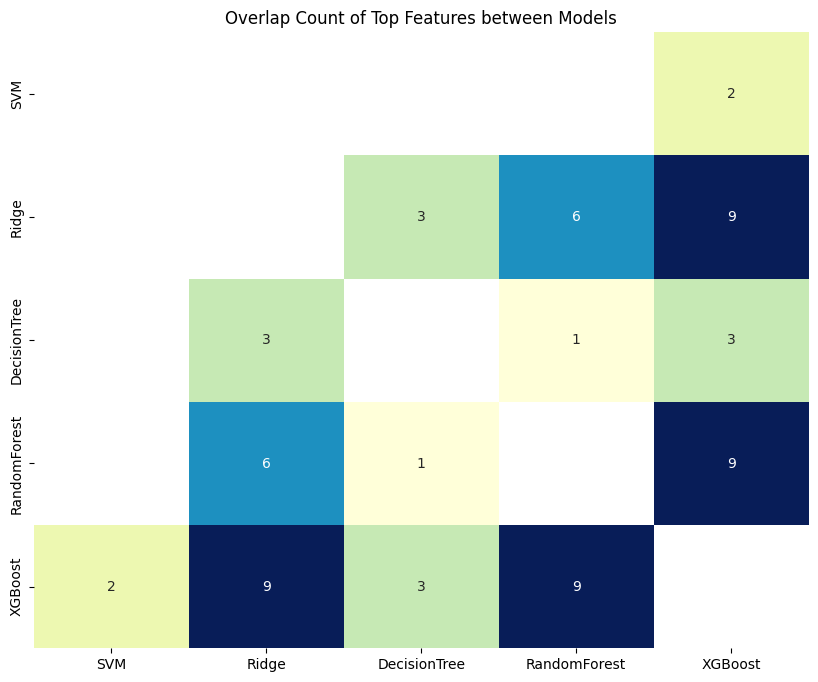

Overlap between SVM and XGBoost: GAB2_5, ACE
Overlap between Ridge and DecisionTree: chr11_snp_62327986, chr13_snp_20336419, chr7_snp_10447804
Overlap between Ridge and RandomForest: chr14_snp_44261301, chr22_snp_25675509, chr13_snp_20336419, chr12_snp_41897399, chr7_snp_33408537, chr10_snp_34857321
Overlap between Ridge and XGBoost: chr11_snp_62327986, chr13_snp_20336419, chr7_snp_10447804, chr12_snp_41897399, chr22_snp_17513184, chr7_snp_33408537, chr20_snp_32119538, chr1_snp_61896198, chr15_snp_52761569
Overlap between DecisionTree and Ridge: chr11_snp_62327986, chr13_snp_20336419, chr7_snp_10447804
Overlap between DecisionTree and RandomForest: chr13_snp_20336419
Overlap between DecisionTree and XGBoost: chr11_snp_62327986, chr13_snp_20336419, chr7_snp_10447804
Overlap between RandomForest and Ridge: chr14_snp_44261301, chr22_snp_25675509, chr13_snp_20336419, chr12_snp_41897399, chr7_snp_33408537, chr10_snp_34857321
Overlap between RandomForest and DecisionTree: chr13_snp_20336419


In [46]:
# 각 모델의 상위 피처를 집합으로 변환
model_feature_sets = {model: set(features) for model, features in model_top_features.items()}

# 겹치는 피처를 찾아 따로 정리
overlap_data = {}
for model1, features1 in model_feature_sets.items():
    for model2, features2 in model_feature_sets.items():
        if model1 != model2:  # 같은 모델끼리는 제외
            overlap = features1 & features2
            if overlap:
                overlap_data[(model1, model2)] = overlap

# 히트맵 데이터 생성
overlap_count = pd.DataFrame(index=model_top_features.keys(), columns=model_top_features.keys(), dtype=int)
for (model1, model2), overlap in overlap_data.items():
    overlap_count.loc[model1, model2] = len(overlap)

# 히트맵 그리기
plt.figure(figsize=(10, 8))
sns.heatmap(overlap_count, annot=True, fmt='g', cmap="YlGnBu", cbar=False)
plt.title("Overlap Count of Top Features between Models")
plt.show()

# 겹치는 값들 정리해서 출력
for (model1, model2), overlap in overlap_data.items():
    print(f"Overlap between {model1} and {model2}: {', '.join(overlap)}")


# 6. map_visualization

In [47]:
import map_visualization

In [48]:
combine_chunks = [[6]]

# 변수 중요도 높은 순으로 snp 100개씩 저장할 딕셔너리
model_top_features = {}

## 중요 변수 데이터프레임 생성하기 - 알츠하이머 관련 snp

In [49]:
# 각 청크 파일들을 합친 후에 실행하고 결과를 출력
for chunks in combine_chunks:
    best_params, svm_accuracy, best_svm_model, selected_df = map_visualization.SVM_model(chunks)
    print(f"Group: 청크 {chunks} 최적 파라미터: {best_params}, 정확도: {svm_accuracy}")
    print("선택한 열:")
    print(selected_df.columns)
    
    # 선택한 열의 데이터 출력
    print("선택한 열의 데이터:")
    print(selected_df)

Group: 청크 [6] 최적 파라미터: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}, 정확도: 0.85
선택한 열:
Index(['GOLM1_1', 'APP ', 'DAPK1_2', 'CALHM1_3', 'PLAU_1', 'PLAU_3', 'MPO',
       'ABCA2', 'TREM2', 'NoGene', 'DNMBP_1', 'SORL1', 'MME', 'GAB2_5',
       'GAB2_1', 'GAB2_4', 'ACE', 'GAB2_3', 'CALHM1_2', 'CETP', 'TLR4',
       'DNMBP_3', 'CALHM1_4', 'A2M', 'ACE_2', 'GAB2_2', 'GAB2', 'BDNF_2',
       'DAPK1_1', 'CALHM1_1', 'BACE1', 'PPP3R1', 'BDNF_1', 'PLAU_2', 'APOE_1',
       'GAB2_6', 'MAPT', 'DNMBP_2', 'APOE_2', 'BDNF_3', 'TM2D3', 'GOLM1_2',
       'OLR1', 'Population code', 'Population', 'Region'],
      dtype='object')
선택한 열의 데이터:
         GOLM1_1  APP   DAPK1_2  CALHM1_3  PLAU_1  PLAU_3  MPO  ABCA2  TREM2  \
HG02645      0.5   0.5      0.0       0.5     1.0     0.5  0.0    0.5    0.0   
HG02466      1.0   0.0      0.0       1.0     1.0     0.5  0.0    0.0    0.0   
HG02652      0.5   0.5      0.0       1.0     1.0     1.0  0.5    0.0    0.0   
HG02734      0.5   0.0      0.5       1.0     1.0   

In [50]:
population_num = selected_df.groupby("Region")["Region"].count()
population_num

Region
ACB    10
BEB     1
CDX     1
ESN    15
GWD    40
KHV     4
MSL     9
PJL    20
Name: Region, dtype: int64

## 지역별 비율

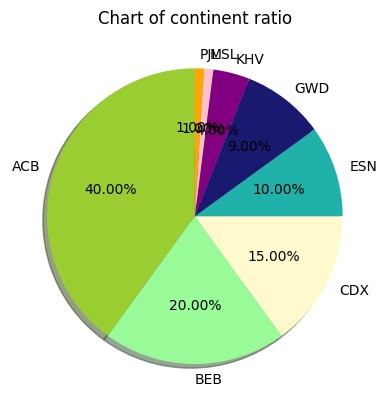

In [51]:
# 지역별 수 
population_num = selected_df["Region"].value_counts()

# 지역 이름
names = ['ACB', 'BEB', 'CDX', 'ESN', 'GWD', 'KHV', 'MSL', 'PJL'] 

# 파이조각이 튀어나올 비율
explode = [0.2 if name == 'AFR' else 0 for name in names]  

# 수정된 색상 리스트
colors = ['yellowgreen', 'palegreen', 'lemonchiffon', 'lightseagreen', 'midnightblue', 'purple', 'pink', 'orange']

plt.title('Chart of continent ratio')
plt.pie(population_num, labels=names, autopct="%.2f%%", shadow=True, explode=explode, counterclock=True, startangle=90, colors=colors)
plt.show()

In [52]:
Region_info = pd.read_csv('./data/Region_info.tsv', sep = '\t')
Region_info

,Population code,Population elastic ID,Population name,Population description,Population latitude,Population longitude,Superpopulation code,Superpopulation name,Superpopulation display colour,Superpopulation display order,Data collections
0,FIN,FIN,Finnish,Finnish in Finland,60.170000,24.930000,EUR,European Ancestry,#018ead,4,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC..."
1,CHS,CHS,Southern Han Chinese,Han Chinese South,23.133330,113.266667,EAS,East Asian Ancestry,#778500,3,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC..."
2,KHV,KHV,Kinh Vietnamese,"Kinh in Ho Chi Minh City, Vietnam",10.780000,106.680000,EAS,East Asian Ancestry,#778500,3,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC..."
3,BEB,BEB,Bengali,Bengali in Bangladesh,23.700000,90.350000,SAS,South Asian Ancestry,#c44cfd,5,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC..."
4,PUR,PUR,Puerto Rican,Puerto Rican in Puerto Rico,18.400000,-66.100000,AMR,American Ancestry,#710027,2,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC..."
5,ACB,ACB,African Caribbean,African Caribbean in Barbados,13.100000,-59.620000,AFR,African Ancestry,#ffd845,1,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC..."
6,ASW,ASW,African Ancestry SW,African Ancestry in Southwest US,35.483000,-97.533330,AFR,African Ancestry,#ffd845,1,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC..."
7,YRI,YRI,Yoruba,"Yoruba in Ibadan, Nigeria",7.400000,3.920000,AFR,African Ancestry,#ffd845,1,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC..."
8,GWD,GWD,Gambian Mandinka,"Gambian in Western Division, The Gambia - Mand...",13.454876,-16.579032,AFR,African Ancestry,#ffd845,1,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC..."
9,JPT,JPT,Japanese,"Japanese in Tokyo, Japan",35.680000,139.680000,EAS,East Asian Ancestry,#778500,3,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC..."


## 지도 시각화

In [54]:
# 국가별 데이터 수 계산
region_counts = pd.DataFrame(selected_df['Region'].value_counts()).reset_index()
region_counts.columns = ['Region', 'count']

# 국가 경계 정보가 담긴 GeoJSON 파일 
geo_path = './data/World_Countries__Generalized_.geojson'
geo_data = json.load(open(geo_path))

# geo_data의 iso코드와 맞춰 국가 데이터 생성
iso_info = pd.DataFrame(data = ['US', 'GM', 'NG', 'CN', 'ES', 'NG', 'PK', 'PR', 'CO', 'BD', 'VN', 'PE', 
                               'BB', 'LK', 'IT', 'IN', 'JP', 'CN', 'US', 'SL', 'KE', 'FI', 'US', 'CN',
                               'UK', 'US'], columns = ['iso_code'])
map_data = pd.concat([iso_info, region_counts], axis = 1)
map_data = map_data.drop(columns=['Region'])
map_data = map_data.groupby('iso_code')['count'].sum().reset_index()

# Folium 지도 생성
m = folium.Map(location=[35.762887375145795, 84.08313219586536], zoom_start=2,
               max_bounds=True, 
               min_zoom=2, min_lat=-84, 
               max_lat=84, min_lon=-175, max_lon=187)

# Choropleth 맵 생성
folium.Choropleth(
    geo_data=geo_data,  
    data=map_data,
    columns=['iso_code', 'count'],  # 'Region' 컬럼과 데이터 수를 연결
    key_on='properties.ISO',  # GeoJSON 파일 내의 국가 코드에 해당하는 부분
    fill_color = 'RdYlGn', 
    fill_opacity = 0.7, 
    line_opacity = 0.5,
    legend_name='Region Counts'
).add_to(m)

m

# 지도를 HTML 파일로 저장
m.save('map_with_colors.html')

## 7. Trio

In [55]:
import Trio

## 부모 정보가 들어있는 텍스트 파일 불러오기

In [56]:
# 텍스트 파일의 경로를 설정하세요.
file_path = './data/parents.txt'

# 텍스트 파일을 데이터 프레임으로 읽어오기
df = pd.read_csv(file_path, delimiter=' ', header=0)  
df = df.set_index('sampleID')
df = df.rename_axis(None)
df

,fatherID,motherID,sex
HG00096,0,0,1
HG00097,0,0,2
HG00099,0,0,2
HG00100,0,0,2
HG00101,0,0,1
...,...,...,...
NA21137,0,0,2
NA21141,0,0,2
NA21142,0,0,2
NA21143,0,0,2


## 부모 정보 추가하기

In [57]:
snp_20 = pd.concat([snp_20, df], axis=1)
snp_20

,PLAU_1,PLAU_2,PLAU_3,TM2D3,GAB2_1,GAB2_2,GAB2_3,GAB2_4,GAB2_5,GAB2_6,...,chr22_snp_41803062,chr22_snp_45608933,chr22_snp_17933615,chr22_snp_21705470,Population code,Population,Region,fatherID,motherID,sex
HG00271,1.0,0.0,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,...,0.0,0.0,0.0,0.0,3.0,EUR,FIN,0,0,1
HG00276,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,3.0,EUR,FIN,0,0,2
HG00288,0.5,0.0,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,...,0.0,0.0,0.0,0.0,3.0,EUR,FIN,0,0,2
HG00290,0.5,0.0,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,...,0.0,0.0,0.0,0.0,3.0,EUR,FIN,0,0,1
HG00308,1.0,0.5,0.5,0.5,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,3.0,EUR,FIN,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NA21117,1.0,0.0,0.5,0.5,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,5.0,SAS,GIH,0,0,1
NA21124,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.5,0.0,...,0.0,0.0,0.0,0.0,5.0,SAS,GIH,0,0,1
NA21129,1.0,0.5,0.5,0.5,0.0,0.0,0.0,0.0,0.5,0.0,...,0.0,0.0,0.0,0.0,5.0,SAS,GIH,0,0,1
NA12236,0.5,0.0,0.0,0.0,0.5,0.5,0.5,0.5,0.5,0.5,...,0.0,0.0,0.0,0.0,3.0,EUR,CEU,0,0,2


In [58]:
# 'HG01783' 샘플 ID를 가진 행 삭제
snp_20 = snp_20.drop(snp_20[snp_20.index == 'HG01783'].index)
snp_20

,PLAU_1,PLAU_2,PLAU_3,TM2D3,GAB2_1,GAB2_2,GAB2_3,GAB2_4,GAB2_5,GAB2_6,...,chr22_snp_41803062,chr22_snp_45608933,chr22_snp_17933615,chr22_snp_21705470,Population code,Population,Region,fatherID,motherID,sex
HG00271,1.0,0.0,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,...,0.0,0.0,0.0,0.0,3.0,EUR,FIN,0,0,1
HG00276,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,3.0,EUR,FIN,0,0,2
HG00288,0.5,0.0,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,...,0.0,0.0,0.0,0.0,3.0,EUR,FIN,0,0,2
HG00290,0.5,0.0,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,...,0.0,0.0,0.0,0.0,3.0,EUR,FIN,0,0,1
HG00308,1.0,0.5,0.5,0.5,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,3.0,EUR,FIN,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NA21112,1.0,0.0,0.5,0.5,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,5.0,SAS,GIH,0,0,1
NA21117,1.0,0.0,0.5,0.5,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,5.0,SAS,GIH,0,0,1
NA21124,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.5,0.0,...,0.0,0.0,0.0,0.0,5.0,SAS,GIH,0,0,1
NA21129,1.0,0.5,0.5,0.5,0.0,0.0,0.0,0.0,0.5,0.0,...,0.0,0.0,0.0,0.0,5.0,SAS,GIH,0,0,1


## 부모가 있는 데이터 뽑아내기

### 아빠가 있는 데이터

In [59]:
filtered_fatherID = snp_20[snp_20['fatherID'] != '0']
filtered_fatherID

,PLAU_1,PLAU_2,PLAU_3,TM2D3,GAB2_1,GAB2_2,GAB2_3,GAB2_4,GAB2_5,GAB2_6,...,chr22_snp_41803062,chr22_snp_45608933,chr22_snp_17933615,chr22_snp_21705470,Population code,Population,Region,fatherID,motherID,sex
HG00423,1.0,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,...,0.0,0.0,0.0,0.0,2.0,EAS,CHS,HG00421,HG00422,2
HG00447,1.0,0.5,0.5,0.5,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,2.0,EAS,CHS,HG00445,HG00446,2
HG00459,0.5,0.5,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,2.0,EAS,CHS,HG00457,HG00458,1
HG00408,0.5,0.0,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,...,0.0,0.0,0.0,0.0,2.0,EAS,CHS,HG00406,HG00407,2
HG00453,0.5,0.0,0.5,0.5,0.5,0.5,0.5,0.5,0.0,0.5,...,0.0,0.0,0.0,0.0,2.0,EAS,CHS,HG00451,HG00452,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NA19100,0.5,0.0,0.5,0.5,0.0,0.0,0.0,0.0,0.5,0.0,...,0.0,0.0,0.0,0.0,0.0,AFR,YRI,NA19098,NA19099,2
NA19129,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,AFR,YRI,NA19128,NA19127,2
NA19763,0.5,0.0,0.0,0.0,0.5,0.5,0.5,0.5,0.5,0.5,...,0.0,0.0,0.0,0.0,1.0,AMR,MXL,NA19762,NA19761,2
NA19775,1.0,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,...,0.0,0.0,0.0,0.0,1.0,AMR,MXL,NA19774,NA19773,2


In [60]:
father_id_zero, filtered_fatherID_nonzero = Trio.find_nonzero_child_snp_for_father(snp_20, filtered_fatherID)
filtered_fatherID_nonzero

,PLAU_1,PLAU_2,PLAU_3,TM2D3,GAB2_1,GAB2_2,GAB2_3,GAB2_4,GAB2_5,GAB2_6,...,chr22_snp_31870000,chr22_snp_50258775,chr22_snp_22428877,chr22_snp_20522123,chr22_snp_46109422,chr22_snp_32812259,chr22_snp_11276039,chr22_snp_25928839,chr22_snp_30032525,chr22_snp_21705470
HG00423,1.0,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HG00447,1.0,0.5,0.5,0.5,NaN,NaN,NaN,NaN,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HG00459,0.5,0.5,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HG00408,0.5,NaN,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HG00453,0.5,NaN,0.5,0.5,0.5,0.5,0.5,0.5,NaN,0.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NA19100,0.5,NaN,0.5,0.5,NaN,NaN,NaN,NaN,0.5,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NA19129,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NA19763,0.5,NaN,NaN,NaN,0.5,0.5,0.5,0.5,0.5,0.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NA19775,1.0,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 엄마가 있는 데이터

In [61]:
filtered_motherID = snp_20[snp_20['motherID'] != '0'] 
filtered_motherID

,PLAU_1,PLAU_2,PLAU_3,TM2D3,GAB2_1,GAB2_2,GAB2_3,GAB2_4,GAB2_5,GAB2_6,...,chr22_snp_41803062,chr22_snp_45608933,chr22_snp_17933615,chr22_snp_21705470,Population code,Population,Region,fatherID,motherID,sex
HG00423,1.0,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,...,0.0,0.0,0.0,0.0,2.0,EAS,CHS,HG00421,HG00422,2
HG00447,1.0,0.5,0.5,0.5,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,2.0,EAS,CHS,HG00445,HG00446,2
HG00459,0.5,0.5,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,2.0,EAS,CHS,HG00457,HG00458,1
HG00408,0.5,0.0,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,...,0.0,0.0,0.0,0.0,2.0,EAS,CHS,HG00406,HG00407,2
HG00453,0.5,0.0,0.5,0.5,0.5,0.5,0.5,0.5,0.0,0.5,...,0.0,0.0,0.0,0.0,2.0,EAS,CHS,HG00451,HG00452,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NA19100,0.5,0.0,0.5,0.5,0.0,0.0,0.0,0.0,0.5,0.0,...,0.0,0.0,0.0,0.0,0.0,AFR,YRI,NA19098,NA19099,2
NA19129,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,AFR,YRI,NA19128,NA19127,2
NA19763,0.5,0.0,0.0,0.0,0.5,0.5,0.5,0.5,0.5,0.5,...,0.0,0.0,0.0,0.0,1.0,AMR,MXL,NA19762,NA19761,2
NA19775,1.0,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,...,0.0,0.0,0.0,0.0,1.0,AMR,MXL,NA19774,NA19773,2


In [62]:
mother_id_zero, filtered_motherID_nonzero = Trio.find_nonzero_child_snp_for_mother(snp_20, filtered_motherID)
filtered_motherID_nonzero

,PLAU_1,PLAU_2,PLAU_3,TM2D3,GAB2_1,GAB2_2,GAB2_3,GAB2_4,GAB2_5,GAB2_6,...,chr22_snp_31870000,chr22_snp_50258775,chr22_snp_22428877,chr22_snp_20522123,chr22_snp_46109422,chr22_snp_32812259,chr22_snp_11276039,chr22_snp_25928839,chr22_snp_30032525,chr22_snp_21705470
HG00423,1.0,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HG00447,1.0,0.5,0.5,0.5,NaN,NaN,NaN,NaN,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HG00459,0.5,0.5,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HG00408,0.5,NaN,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HG00453,0.5,NaN,0.5,0.5,0.5,0.5,0.5,0.5,NaN,0.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NA19100,0.5,NaN,0.5,0.5,NaN,NaN,NaN,NaN,0.5,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NA19129,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NA19763,0.5,NaN,NaN,NaN,0.5,0.5,0.5,0.5,0.5,0.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NA19775,1.0,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [63]:
combined_df = pd.concat([filtered_motherID_nonzero, filtered_fatherID_nonzero], axis=1)
combined_df = combined_df[combined_df.columns[:43]]
combined_df['fatherID'] = combined_df.index.map(lambda x: snp_20.loc[x]['fatherID'])
combined_df['motherID'] = combined_df.index.map(lambda x: snp_20.loc[x]['motherID'])
combined_df['Region'] = combined_df.index.map(lambda x: snp_20.loc[x]['Region'])

In [64]:
combined_df

,PLAU_1,PLAU_1,PLAU_2,PLAU_2,PLAU_3,PLAU_3,TM2D3,TM2D3,GAB2_1,GAB2_1,...,MME,TLR4,TLR4,PPP3R1,PPP3R1,CETP,CETP,fatherID,motherID,Region
HG00423,1.0,1.0,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,...,NaN,NaN,NaN,0.5,0.5,0.5,0.5,HG00421,HG00422,CHS
HG00447,1.0,1.0,0.5,0.5,0.5,0.5,0.5,0.5,NaN,NaN,...,NaN,NaN,NaN,1.0,1.0,0.5,0.5,HG00445,HG00446,CHS
HG00459,0.5,0.5,0.5,0.5,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.0,1.0,0.5,0.5,HG00457,HG00458,CHS
HG00408,0.5,0.5,NaN,NaN,0.5,0.5,0.5,0.5,0.5,0.5,...,NaN,NaN,NaN,1.0,1.0,NaN,NaN,HG00406,HG00407,CHS
HG00453,0.5,0.5,NaN,NaN,0.5,0.5,0.5,0.5,0.5,0.5,...,NaN,NaN,NaN,1.0,1.0,1.0,1.0,HG00451,HG00452,CHS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NA19129,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,...,NaN,NaN,NaN,1.0,1.0,0.5,0.5,NA19128,NA19127,YRI
NA19763,0.5,0.5,NaN,NaN,NaN,NaN,NaN,NaN,0.5,0.5,...,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NA19762,NA19761,MXL
NA19775,1.0,1.0,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,...,NaN,NaN,NaN,1.0,1.0,0.5,0.5,NA19774,NA19773,MXL
NA19787,1.0,1.0,0.5,0.5,NaN,NaN,NaN,NaN,0.5,0.5,...,NaN,NaN,NaN,1.0,1.0,1.0,1.0,NA19786,NA19785,MXL


### 부모가 둘다 있는 데이터

In [65]:
parentsID_child_nonzero = {}

In [66]:
filtered_parentsID = combined_df[(combined_df['fatherID'] != '0')&(combined_df['motherID'] != '0')]
filtered_parentsID

,PLAU_1,PLAU_1,PLAU_2,PLAU_2,PLAU_3,PLAU_3,TM2D3,TM2D3,GAB2_1,GAB2_1,...,MME,TLR4,TLR4,PPP3R1,PPP3R1,CETP,CETP,fatherID,motherID,Region
HG00423,1.0,1.0,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,...,NaN,NaN,NaN,0.5,0.5,0.5,0.5,HG00421,HG00422,CHS
HG00447,1.0,1.0,0.5,0.5,0.5,0.5,0.5,0.5,NaN,NaN,...,NaN,NaN,NaN,1.0,1.0,0.5,0.5,HG00445,HG00446,CHS
HG00459,0.5,0.5,0.5,0.5,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.0,1.0,0.5,0.5,HG00457,HG00458,CHS
HG00408,0.5,0.5,NaN,NaN,0.5,0.5,0.5,0.5,0.5,0.5,...,NaN,NaN,NaN,1.0,1.0,NaN,NaN,HG00406,HG00407,CHS
HG00453,0.5,0.5,NaN,NaN,0.5,0.5,0.5,0.5,0.5,0.5,...,NaN,NaN,NaN,1.0,1.0,1.0,1.0,HG00451,HG00452,CHS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NA19100,0.5,0.5,NaN,NaN,0.5,0.5,0.5,0.5,NaN,NaN,...,0.5,0.5,0.5,0.5,0.5,0.5,0.5,NA19098,NA19099,YRI
NA19129,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,...,NaN,NaN,NaN,1.0,1.0,0.5,0.5,NA19128,NA19127,YRI
NA19763,0.5,0.5,NaN,NaN,NaN,NaN,NaN,NaN,0.5,0.5,...,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NA19762,NA19761,MXL
NA19775,1.0,1.0,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,...,NaN,NaN,NaN,1.0,1.0,0.5,0.5,NA19774,NA19773,MXL


In [67]:
duplicated_columns = filtered_parentsID.columns[filtered_parentsID.columns.duplicated()]
print("중복된 컬럼:", duplicated_columns)

중복된 컬럼: Index(['PLAU_1', 'PLAU_2', 'PLAU_3', 'TM2D3', 'GAB2_1', 'GAB2_2', 'GAB2_3',
       'GAB2_4', 'GAB2_5', 'GAB2_6', 'A2M', 'CALHM1_1', 'CALHM1_2', 'CALHM1_3',
       'CALHM1_4', 'GOLM1_1', 'GOLM1_2', 'NoGene', 'BDNF_1', 'BDNF_2',
       'BDNF_3', 'DNMBP_1', 'DNMBP_2', 'DNMBP_3', 'ACE_2', 'MAPT', 'APOE_1',
       'APOE_2', 'SORL1', 'ABCA2', 'GAB2', 'BACE1', 'APP ', 'TREM2', 'OLR1',
       'ACE', 'MPO', 'DAPK1_1', 'DAPK1_2', 'MME', 'TLR4', 'PPP3R1', 'CETP'],
      dtype='object')


In [68]:
filtered_parentsID = filtered_parentsID.loc[:, filtered_parentsID.columns.duplicated()]
filtered_parentsID['fatherID'] = filtered_parentsID.index.map(lambda x: combined_df.loc[x]['fatherID'])
filtered_parentsID['motherID'] = filtered_parentsID.index.map(lambda x: combined_df.loc[x]['motherID'])
filtered_parentsID['Region'] = filtered_parentsID.index.map(lambda x: combined_df.loc[x]['Region'])
filtered_parentsID

,PLAU_1,PLAU_2,PLAU_3,TM2D3,GAB2_1,GAB2_2,GAB2_3,GAB2_4,GAB2_5,GAB2_6,...,MPO,DAPK1_1,DAPK1_2,MME,TLR4,PPP3R1,CETP,fatherID,motherID,Region
HG00423,1.0,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,...,0.5,0.5,0.5,NaN,NaN,0.5,0.5,HG00421,HG00422,CHS
HG00447,1.0,0.5,0.5,0.5,NaN,NaN,NaN,NaN,1.0,NaN,...,0.5,0.5,0.5,NaN,NaN,1.0,0.5,HG00445,HG00446,CHS
HG00459,0.5,0.5,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,...,0.5,NaN,NaN,NaN,NaN,1.0,0.5,HG00457,HG00458,CHS
HG00408,0.5,NaN,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,...,NaN,0.5,0.5,NaN,NaN,1.0,NaN,HG00406,HG00407,CHS
HG00453,0.5,NaN,0.5,0.5,0.5,0.5,0.5,0.5,NaN,0.5,...,NaN,0.5,0.5,NaN,NaN,1.0,1.0,HG00451,HG00452,CHS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NA19100,0.5,NaN,0.5,0.5,NaN,NaN,NaN,NaN,0.5,NaN,...,NaN,NaN,NaN,0.5,0.5,0.5,0.5,NA19098,NA19099,YRI
NA19129,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,1.0,0.5,NA19128,NA19127,YRI
NA19763,0.5,NaN,NaN,NaN,0.5,0.5,0.5,0.5,0.5,0.5,...,0.5,0.5,0.5,NaN,NaN,1.0,NaN,NA19762,NA19761,MXL
NA19775,1.0,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,...,NaN,0.5,0.5,NaN,NaN,1.0,0.5,NA19774,NA19773,MXL


In [69]:
duplicated_columns = filtered_parentsID.columns[filtered_parentsID.columns.duplicated()]
print("중복된 컬럼:", duplicated_columns)

중복된 컬럼: Index([], dtype='object')


In [70]:
# 데이터프레임의 각 행에 대해 반복
for i, row in filtered_parentsID.iterrows():
    non_nan_values = Trio.nonnan_values(row)
    parentsID_child_nonzero[i] = non_nan_values
parentsID_child_nonzero

{'HG00423': PLAU_1          1.0
 PLAU_2          0.5
 PLAU_3          0.5
 TM2D3           0.5
 GAB2_1          0.5
 GAB2_2          0.5
 GAB2_3          0.5
 GAB2_4          0.5
 GAB2_5          0.5
 GAB2_6          0.5
 A2M             0.5
 CALHM1_1        0.5
 CALHM1_2        1.0
 CALHM1_3        1.0
 CALHM1_4        0.5
 GOLM1_1         0.5
 GOLM1_2         0.5
 NoGene          1.0
 DNMBP_1         1.0
 DNMBP_2         1.0
 DNMBP_3         1.0
 ACE_2           0.5
 MAPT            1.0
 APOE_1          0.5
 APOE_2          0.5
 SORL1           1.0
 ABCA2           1.0
 GAB2            0.5
 OLR1            0.5
 ACE             0.5
 MPO             0.5
 DAPK1_1         0.5
 DAPK1_2         0.5
 PPP3R1          0.5
 CETP            0.5
 fatherID    HG00421
 motherID    HG00422
 Region          CHS
 Name: HG00423, dtype: object,
 'HG00447': PLAU_1          1.0
 PLAU_2          0.5
 PLAU_3          0.5
 TM2D3           0.5
 GAB2_5          1.0
 A2M             0.5
 CALHM1_1        0.5
 C

In [71]:
# 지역별로 몇개인지 확인
grouped = filtered_parentsID.groupby('Region').count()
grouped['mean'] = grouped.mean(axis=1)
grouped['percent'] = grouped.mean(axis=1)/grouped['motherID']*100
grouped

,PLAU_1,PLAU_2,PLAU_3,TM2D3,GAB2_1,GAB2_2,GAB2_3,GAB2_4,GAB2_5,GAB2_6,...,DAPK1_1,DAPK1_2,MME,TLR4,PPP3R1,CETP,fatherID,motherID,mean,percent
Region,,,,,,,,,,,,,,,,,,,,,
ACB,20,6,15,15,12,12,9,9,13,13,...,7,7,5,5,19,13,20,20,10.377778,51.888889
ASW,9,3,5,5,8,10,5,5,6,9,...,4,4,2,2,13,8,13,13,6.377778,49.059829
BEB,29,10,19,19,19,19,17,17,21,20,...,10,10,8,8,26,26,30,30,16.800000,56.000000
CEU,54,16,27,27,38,42,37,37,20,42,...,15,15,15,15,53,46,57,57,31.111111,54.580897
CHS,45,14,30,30,19,22,13,13,37,23,...,28,28,12,12,47,38,51,51,25.511111,50.021786
CLM,30,11,12,12,20,20,11,11,17,20,...,15,15,5,5,33,29,35,35,17.777778,50.793651
ESN,36,12,24,24,20,19,15,15,32,21,...,17,17,11,11,41,39,43,43,22.400000,52.093023
GWD,49,21,28,28,32,34,30,30,39,34,...,19,19,13,13,52,40,58,58,30.088889,51.877395
IBS,48,13,26,26,29,32,18,18,29,32,...,23,23,14,14,46,37,50,50,25.800000,51.600000
